In [246]:
import sys
!"{sys.executable}" -m pip show spacy
!"{sys.executable}" -m pip install -U spacy
!"{sys.executable}" -m spacy download en_core_web_sm

Name: spacy
Version: 3.8.14
Summary: Industrial-strength Natural Language Processing (NLP) in Python
Home-page: https://spacy.io
Author: Explosion
Author-email: contact@explosion.ai
License: MIT
Location: C:\Users\CE PC\anaconda3\Lib\site-packages
Requires: catalogue, confection, cymem, jinja2, murmurhash, numpy, packaging, preshed, pydantic, requests, setuptools, spacy-legacy, spacy-loggers, srsly, thinc, tqdm, typer, wasabi, weasel
Required-by: 
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 3.8 MB/s eta 0:00:04
     -- ------------------------------------- 0.8/12.8 MB 3.4 MB/s eta 0:00:04
     ---- ----------------------------------- 1.6/12.8 MB 2.7 MB/s eta 0:00:05
     ---- ----------------------------------- 1.6/12.8 MB 2.7 MB/s eta 0:00:05
     ------ --------------------------------- 2.1/12.8 MB 2.1 MB/s eta 0:00:06
     ----

In [247]:
%pip install wordcloud
%pip install xgboost
%pip install gensim

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [248]:
import pandas as pd
import re
import string
import numpy as np
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import spacy
from sklearn.naive_bayes import MultinomialNB
from spacy.tokenizer import Tokenizer
from spacy.lang.en import English
from sklearn.model_selection import train_test_split
nlp = spacy.load("en_core_web_sm")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
import seaborn as sns
import plotly.figure_factory as ff
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from gensim.models import Word2Vec
from sklearn.base import BaseEstimator, TransformerMixin

In [249]:
# Importation des données
df = pd.read_csv("tweets.csv")
df.head(5)

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


Dans cette première étape, nous importons la base de données contenant les tweets. L’objectif est de vérifier que les données sont bien chargées et d’avoir un premier aperçu des variables disponibles.

In [250]:
df.isnull().sum()

id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

On remarque que seule la variable location contient des valeurs manquantes

In [251]:
df.shape

(11370, 5)

C:\Users\CE PC\AppData\Local\Temp\ipykernel_30304\2329482365.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




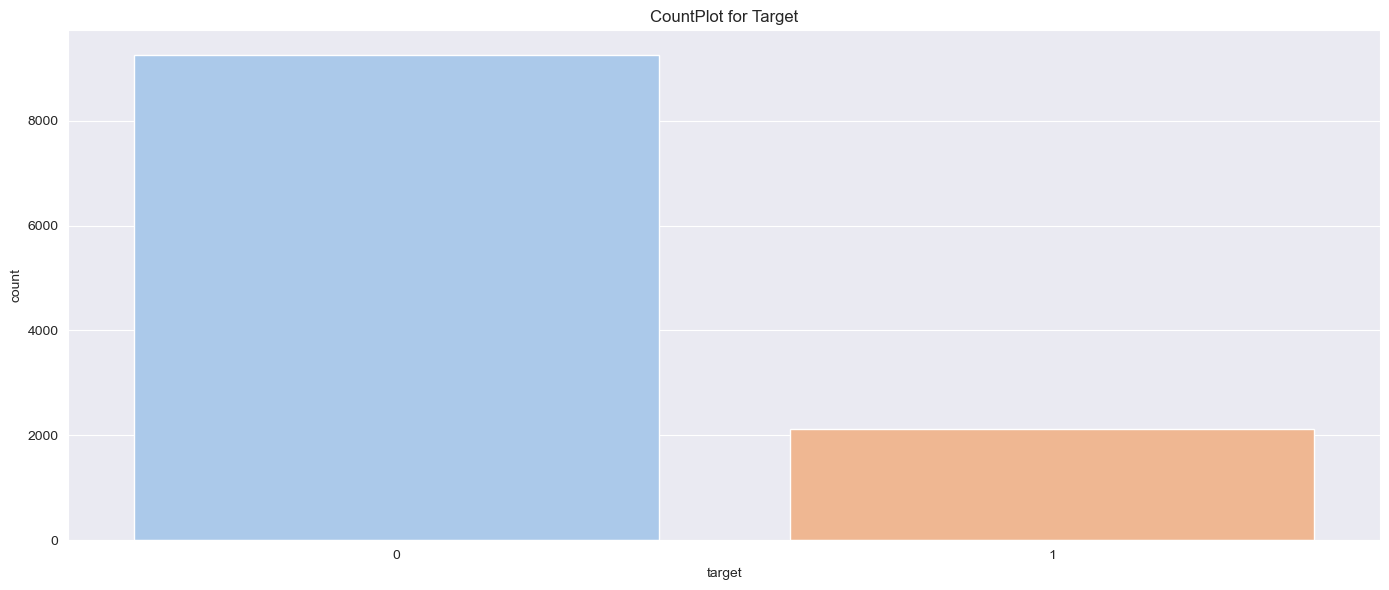

In [252]:
plt.figure(figsize=(14,6))
sns.set_style('darkgrid')
sns.countplot(data=df, x='target', palette='pastel')
plt.title('CountPlot for Target')
plt.tight_layout()
plt.show()

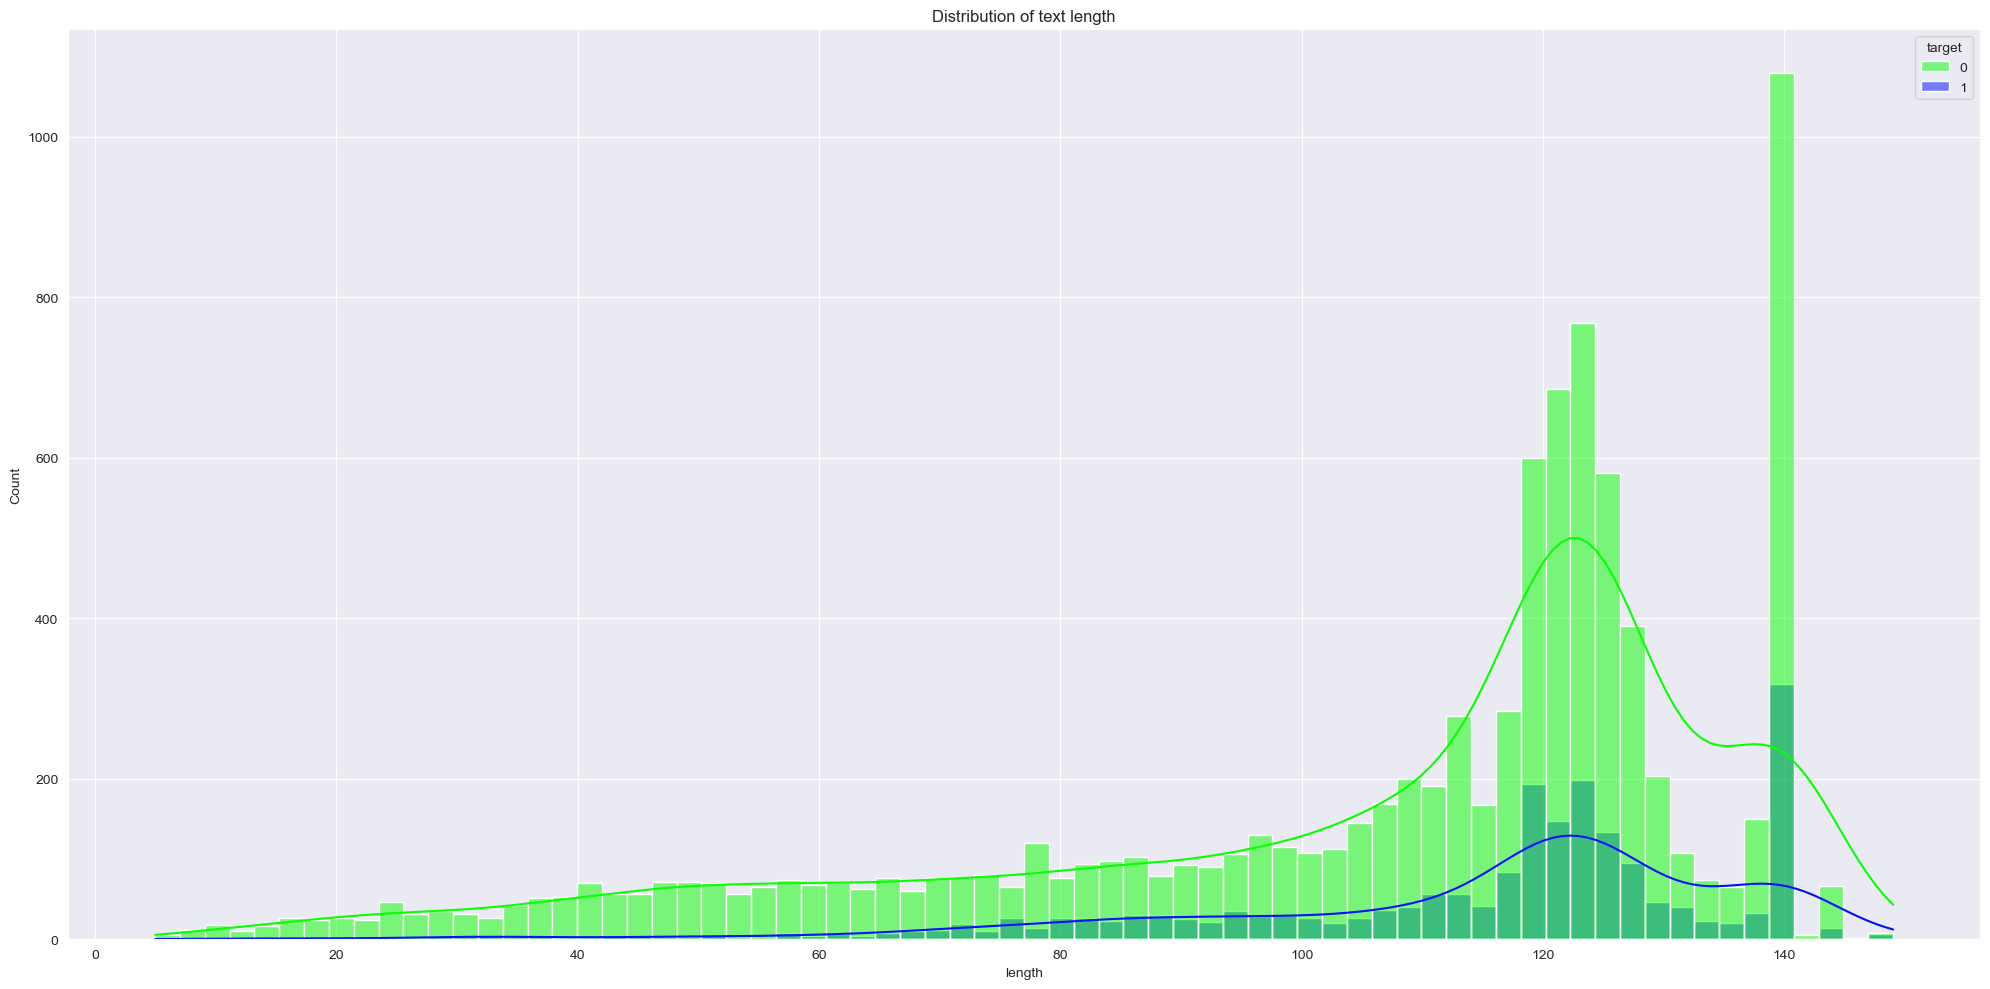

In [253]:
df['length'] = df['text'].apply(len)
plt.figure(figsize=(20,10))
sns.histplot(data=df, x='length', hue='target', palette='hsv', kde=True, bins=70)
plt.title('Distribution of text length')
plt.tight_layout()
plt.show()

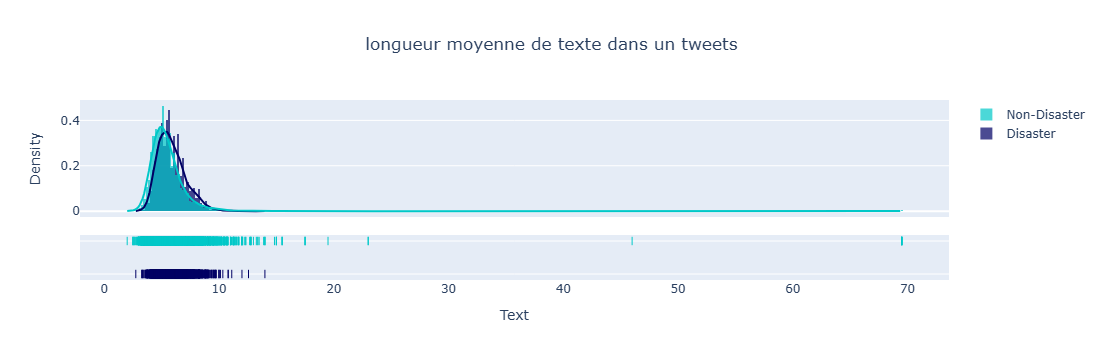

In [254]:
def avgwordlen(strlist):
    sum=[]
    for i in strlist:
        sum.append(len(i))
    return sum

avgword_len_dis = df[df['target']==1]['text'].str.split().apply(avgwordlen).map(lambda x: np.mean(x))

avgword_len_non_dis = df[df['target']==0]['text'].str.split().apply(avgwordlen).map(lambda x: np.mean(x))
group_labels = ['Disaster', 'Non-Disaster']
colors = ['rgb(0, 0, 100)', 'rgb(0, 200, 200)']

fig = ff.create_distplot([avgword_len_dis, avgword_len_non_dis], group_labels, bin_size=.2, colors=colors,)

fig.update_layout(title_text="longueur moyenne de texte dans un tweets",title_x=0.5,xaxis_title="Text",yaxis_title="Density").show()


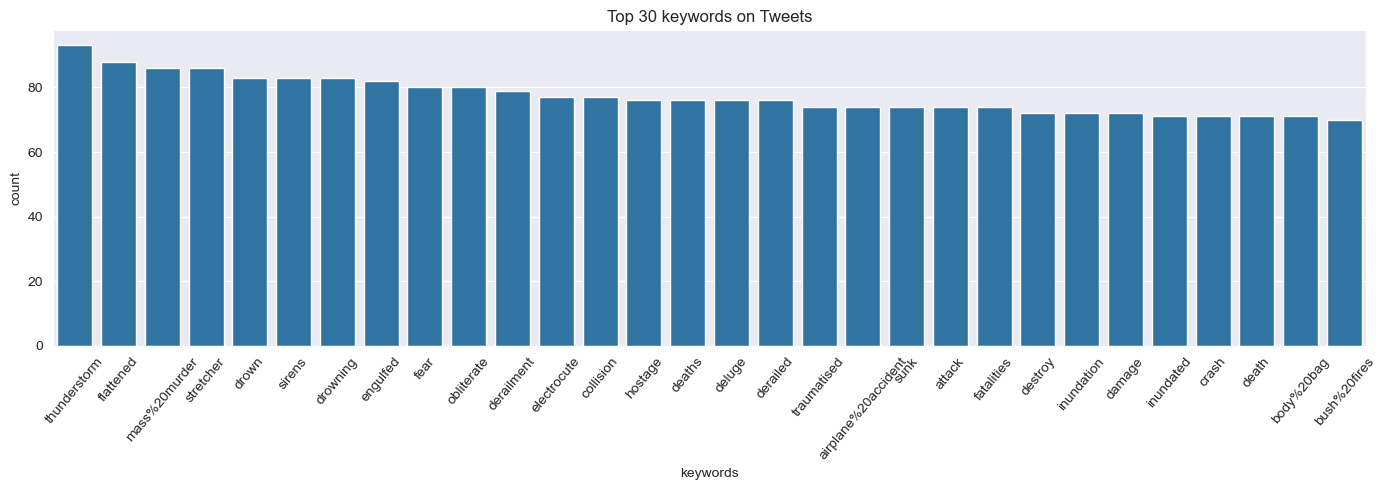

In [255]:
# Grouping by Keywords to see the count of keywords
keyword = df.groupby('keyword')['target'].count()
df_key = pd.DataFrame({'keywords':keyword.index,'count':keyword.values}).sort_values(by='count',ascending=False)

# Top 30 keywords in the Tweets.
plt.figure(figsize=(14,5))
sns.barplot(data=df_key.head(30),x='keywords',y='count')
plt.xticks(rotation = 50)
plt.title('Top 30 keywords on Tweets')
plt.tight_layout()
plt.show()

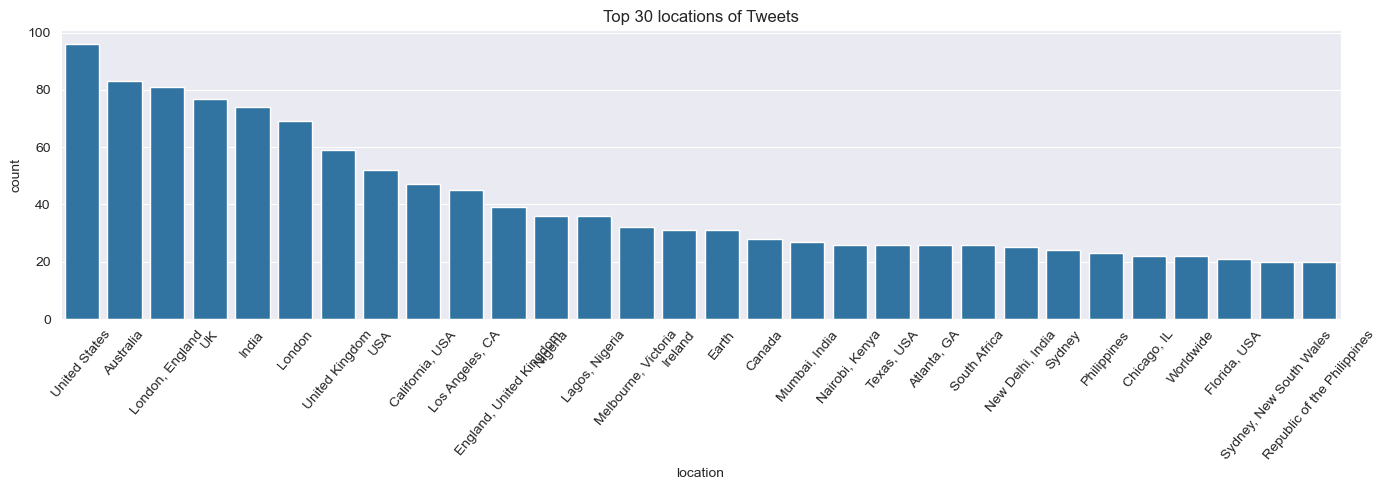

In [256]:
# Grouping by Location to find the count of each location
location = df.groupby('location')['target'].count()
df_loc = pd.DataFrame({'location':location.index,'count':location.values}).sort_values(by='count',ascending=False)

# Top 30 Location in the tweets
plt.figure(figsize=(14,5))
sns.barplot(data=df_loc.head(30),x='location',y='count')
plt.xticks(rotation = 50)
plt.title('Top 30 locations of Tweets')
plt.tight_layout()
plt.show()

# Fetaure Enginering

Tout d’abord, nous convertissons tous les mots en minuscules.
Ensuite, nous supprimons la ponctuation, les caractères spéciaux, les espaces superflus, supprimer les émoticônes,  supprimer les symboles et pictogrammes, supprimer les drapeaux,...

**Text_Cleaning**

In [257]:
def cleaning_simple(data):
    text = str(data)  # convertir en texte pour éviter les erreurs avec les valeurs manquantes
    
    text = re.sub(r'https?://\S+|www\.\S+|http?://\S+', ' ', text)  # supprimer les URLs
    
    text = re.sub(r'<.*?>', ' ', text)  # supprimer les balises HTML
    
    text = re.sub("["
                  u"\U0001F600-\U0001F64F"
                  u"\U0001F300-\U0001F5FF"
                  u"\U0001F680-\U0001F6FF"
                  u"\U0001F1E0-\U0001F1FF"
                  u"\U00002702-\U000027B0"
                  u"\U000024C2-\U0001F251"
                  "]+", ' ', text)  # supprimer les émojis et symboles
    
    text = re.sub(r'@\S+', ' ', text)  # supprimer les mentions @user
    
    text = re.sub(r'#', '', text)  # supprimer le symbole # mais garder le mot
    
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # garder uniquement les lettres et les espaces
    
    text = text.lower()  # convertir en minuscules
    
    text = re.sub(r'\s+', ' ', text).strip()  # supprimer les espaces multiples
    
    return text

In [258]:
df["text_clean"] = df["text"].apply(cleaning_simple)
df["keyword_clean"] = df["keyword"].fillna("").apply(cleaning_simple)

Dans cette étape, nous nettoyons les variables `text` et `keyword`.  
L’objectif est uniquement de retirer les éléments bruités comme les URLs, les balises HTML, les mentions, les émojis, les caractères spéciaux et les espaces multiples.  
Les textes sont également convertis en minuscules afin d’uniformiser l’écriture.

**Tokenisation des tweets**

La tokenisation consiste à découper un texte en petites unités appelées *tokens*, généralement des mots.

Cette étape permet de transformer une phrase complète en une liste de mots individuels afin de faciliter les traitements de NLP. La tokenisation constitue souvent la première étape d’un pipeline de prétraitement textuel.

In [259]:
# Chargement de spaCy
nlp = spacy.load("en_core_web_sm")

In [260]:
# Application de la tokenisation (en mots) sur la variable texte
df["tokens"] = df["text_clean"].apply(
    lambda texte: [token.text for token in nlp(str(texte))]
)

In [261]:
# Affichage des résultats de la tekenisation
df[["text_clean", "tokens"]].head()

,text_clean,tokens
0,communal violence in bhainsa telangana stones ...,"[communal, violence, in, bhainsa, telangana, s..."
1,telangana section has been imposed in bhainsa ...,"[telangana, section, has, been, imposed, in, b..."
2,arsonist sets cars ablaze at dealership,"[arsonist, sets, cars, ablaze, at, dealership]"
3,arsonist sets cars ablaze at dealership,"[arsonist, sets, cars, ablaze, at, dealership]"
4,lord jesus your love brings freedom and pardon...,"[lord, jesus, your, love, brings, freedom, and..."


Chaque tweet est désormais représenté sous forme d’une liste de mots et symboles. Cette représentation permet de préparer les étapes suivantes du pipeline de prétraitement, comme la suppression des mots vides, le nettoyage ou la lemmatisation.

**POS Tagging (Part-Of-Speech Tagging)**

Le POS Tagging consiste à attribuer à chaque mot sa catégorie grammaticale dans une phrase.

Chaque token peut ainsi être identifié comme :
- un nom (NOUN),
- un verbe (VERB),
- un adjectif (ADJ),
- un adverbe (ADV),
- etc.
Cette étape permet de mieux comprendre la structure grammaticale des tweets et facilite certaines opérations avancées de NLP, notamment la lemmatisation et l’analyse sémantique.

In [262]:
# POS tagging sur les tokens
df["pos_tags"] = df["tokens"].apply(
    lambda tokens: [(token.text, token.pos_) for token in nlp(" ".join(tokens))]
)

# Affichage des résultats
df[["tokens", "pos_tags"]].head()

,tokens,pos_tags
0,"[communal, violence, in, bhainsa, telangana, s...","[(communal, ADJ), (violence, NOUN), (in, ADP),..."
1,"[telangana, section, has, been, imposed, in, b...","[(telangana, PROPN), (section, PROPN), (has, A..."
2,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),..."
3,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),..."
4,"[lord, jesus, your, love, brings, freedom, and...","[(lord, PROPN), (jesus, PROPN), (your, PRON), ..."


Après la tokenisation, nous appliquons le POS tagging afin d’associer chaque token à sa catégorie grammaticale. Pour cela, les tokens sont temporairement recombinés en texte afin que spaCy puisse attribuer les étiquettes grammaticales à chaque mot.

**Suppression des stopwords (créer une liste plus exhaustive)**

Les stopwords sont des mots très fréquents dans une langue qui apportent généralement peu d’information pour la classification des textes. Il s’agit par exemple de mots comme : *the*, *is*, *and*, *in*, etc.

L’objectif de cette étape est de conserver uniquement les mots les plus informatifs afin de réduire le bruit dans les données textuelles.

In [263]:
# Filtrage des tokens selon leur catégorie grammaticale
df["tokens_pos_utiles"] = df["pos_tags"].apply(
    lambda pos_tags: [
        mot for mot, pos in pos_tags
        if pos in ["NOUN", "VERB", "ADJ", "ADV", "PROPN"]
    ]
)

# Affichage des résultats
df[["tokens", "pos_tags", "tokens_pos_utiles"]].head()


,tokens,pos_tags,tokens_pos_utiles
0,"[communal, violence, in, bhainsa, telangana, s...","[(communal, ADJ), (violence, NOUN), (in, ADP),...","[communal, violence, bhainsa, telangana, stone..."
1,"[telangana, section, has, been, imposed, in, b...","[(telangana, PROPN), (section, PROPN), (has, A...","[telangana, section, imposed, bhainsa, january..."
2,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]"
3,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]"
4,"[lord, jesus, your, love, brings, freedom, and...","[(lord, PROPN), (jesus, PROPN), (your, PRON), ...","[lord, jesus, love, brings, freedom, pardon, f..."


In [264]:
# Supprimer ces textes

# Sélection des tweets ne contenant aucun token grammatical utile
tweets_sans_pos_utiles = df[
    df["tokens_pos_utiles"].apply(len) == 0
]

# Affichage des textes concernés
tweets_sans_pos_utiles[
    ["text_clean", "tokens", "pos_tags", "tokens_pos_utiles"]
]

,text_clean,tokens,pos_tags,tokens_pos_utiles
337,,[],[],[]
688,,[],[],[]
1500,i will,"[i, will]","[(i, PRON), (will, AUX)]",[]
4449,,[],[],[]
6204,hello,[hello],"[(hello, INTJ)]",[]
8029,,[],[],[]
8030,,[],[],[]
10862,,[],[],[]


Après l’application du POS tagging, un filtrage grammatical a été effectué afin de conserver uniquement les catégories de mots considérées comme les plus informatives pour l’analyse textuelle, notamment :

les noms (NOUN),
les verbes (VERB),
les adjectifs (ADJ),
les adverbes (ADV),
ainsi que les noms propres (PROPN).

L’objectif de cette étape est de réduire le bruit linguistique en supprimant les mots moins pertinents sur le plan sémantique, tout en conservant les termes les plus susceptibles de porter une information utile pour la classification des tweets.

In [265]:
# Nombre de tweets contenant au moins un token grammatical utile
nb_tweets_utiles = (df["tokens_pos_utiles"].apply(len) > 0).sum()

# Nombre total de tweets
nb_total = len(df)

# Pourcentage
pourcentage = round((nb_tweets_utiles / nb_total) * 100, 2)

print("Nombre de tweets contenant des tokens utiles :", nb_tweets_utiles)
print("Nombre total de tweets :", nb_total)
print("Pourcentage :", pourcentage, "%")

Nombre de tweets contenant des tokens utiles : 11362
Nombre total de tweets : 11370
Pourcentage : 99.93 %


Les résultats obtenus montrent que 11 362 tweets sur 11 370, soit 99,93 % des tweets, contiennent au moins un token grammatical jugé utile après le filtrage. Cela signifie que presque tous les tweets de la base possèdent des mots porteurs de sens appartenant aux catégories grammaticales retenues.

Ce résultat est particulièrement intéressant, car il montre que :

les tweets contiennent généralement une information textuelle exploitable ;
le filtrage grammatical ne provoque pas une perte importante d’information ;
les catégories grammaticales sélectionnées couvrent efficacement le contenu des tweets.

Par ailleurs, le très faible nombre de tweets ne contenant aucun token utile après filtrage suggère que la majorité des messages restent suffisamment riches sur le plan lexical pour être exploités dans les étapes suivantes du pipeline NLP.

In [266]:
# Suppression des stopwords après filtrage POS
df["tokens_pos_sans_stopwords"] = df["tokens_pos_utiles"].apply(
    lambda tokens: [
        token.text for token in nlp(" ".join(tokens))
        if not token.is_stop
    ]
)

# Affichage des résultats
df[["tokens_pos_utiles", "tokens_pos_sans_stopwords"]].head()

,tokens_pos_utiles,tokens_pos_sans_stopwords
0,"[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone..."
1,"[telangana, section, imposed, bhainsa, january...","[telangana, section, imposed, bhainsa, january..."
2,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]"
3,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]"
4,"[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, brings, freedom, pardon, f..."


Après le filtrage grammatical, les stopwords ont été supprimés afin d’éliminer les mots très fréquents et peu informatifs comme the, is, and ou in. Cette étape permet de réduire le bruit dans les données textuelles et de conserver principalement les mots les plus utiles pour la classification des tweets. Les textes obtenus sont ainsi plus légers, plus pertinents et mieux adaptés aux méthodes de vectorisation (TF-IDF, ...) ainsi qu’aux modèles de machine learning.

**Lemmatisation**

In [267]:
# Lemmatisation après suppression des stopwords
df["tokens_lemmatized"] = df["tokens_pos_sans_stopwords"].apply(
    lambda tokens: [
        token.lemma_ for token in nlp(" ".join(tokens))
    ]
)
# Affichage des résultats
df[["tokens_pos_sans_stopwords", "tokens_lemmatized"]].head()

,tokens_pos_sans_stopwords,tokens_lemmatized
0,"[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone..."
1,"[telangana, section, imposed, bhainsa, january...","[telangana, section, impose, bhainsa, january,..."
2,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
3,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
4,"[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, bring, freedom, pardon, fi..."


La lemmatisation consiste à ramener chaque mot à sa forme de base appelée lemme. Par exemple, *running*, *runs* et ran seront ramenés à *run*. Cette étape permet de regrouper différentes formes d’un même mot afin de réduire la taille du vocabulaire et d’améliorer la qualité de la représentation textuelle avant la vectorisation et la modélisation.

In [268]:
df.head(10)

,id,keyword,location,text,target,length,text_clean,keyword_clean,tokens,pos_tags,tokens_pos_utiles,tokens_pos_sans_stopwords,tokens_lemmatized
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1,125,communal violence in bhainsa telangana stones ...,ablaze,"[communal, violence, in, bhainsa, telangana, s...","[(communal, ADJ), (violence, NOUN), (in, ADP),...","[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone..."
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1,131,telangana section has been imposed in bhainsa ...,ablaze,"[telangana, section, has, been, imposed, in, b...","[(telangana, PROPN), (section, PROPN), (has, A...","[telangana, section, imposed, bhainsa, january...","[telangana, section, imposed, bhainsa, january...","[telangana, section, impose, bhainsa, january,..."
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1,63,arsonist sets cars ablaze at dealership,ablaze,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1,87,arsonist sets cars ablaze at dealership,ablaze,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0,140,lord jesus your love brings freedom and pardon...,ablaze,"[lord, jesus, your, love, brings, freedom, and...","[(lord, PROPN), (jesus, PROPN), (your, PRON), ...","[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, bring, freedom, pardon, fi..."
5,5,ablaze,OC,"If this child was Chinese, this tweet would ha...",0,122,if this child was chinese this tweet would hav...,ablaze,"[if, this, child, was, chinese, this, tweet, w...","[(if, SCONJ), (this, DET), (child, NOUN), (was...","[child, chinese, tweet, gone, viral, social, m...","[child, chinese, tweet, gone, viral, social, m...","[child, chinese, tweet, go, viral, social, med..."
6,6,ablaze,"London, England",Several houses have been set ablaze in Ngemsib...,1,139,several houses have been set ablaze in ngemsib...,ablaze,"[several, houses, have, been, set, ablaze, in,...","[(several, ADJ), (houses, NOUN), (have, AUX), ...","[several, houses, set, ablaze, ngemsibaa, vill...","[houses, set, ablaze, ngemsibaa, village, oku,...","[house, set, ablaze, ngemsibaa, village, oku, ..."
7,7,ablaze,Bharat,Asansol: A BJP office in Salanpur village was ...,1,131,asansol a bjp office in salanpur village was s...,ablaze,"[asansol, a, bjp, office, in, salanpur, villag...","[(asansol, PROPN), (a, DET), (bjp, PROPN), (of...","[asansol, bjp, office, salanpur, village, set,...","[asansol, bjp, office, salanpur, village, set,...","[asansol, bjp, office, salanpur, village, set,..."
8,8,ablaze,"Accra, Ghana","National Security Minister, Kan Dapaah's side ...",0,135,national security minister kan dapaah s side c...,ablaze,"[national, security, minister, kan, dapaah, s,...","[(national, ADJ), (security, PROPN), (minister...","[national, security, minister, kan, dapaah, si...","[national, security, minister, kan, dapaah, ch...","[national, security, minister, kan, dapaah, ch..."
9,9,ablaze,Searching,This creature who’s soul is no longer clarent ...,0,127,this creature who s soul is no longer clarent ...,ablaze,"[this, creature, who, s, soul, is, no, longer,...","[(this, DET), (creature, NOUN), (who, PRON), (...","[creature, s, soul, longer, clarent, blue, abl...","[creature, s, soul, longer, clarent, blue, abl...","[creature, s, soul, long, clarent, b

# Analyse de la variable Keyword

**Lemmatisation**

In [269]:
df["keyword_lemma"] = df["keyword_clean"].apply(
    lambda texte: " ".join(
        [token.lemma_ for token in nlp(texte)]
    )
)

In [270]:
df["keyword_lemma"].unique()

array(['ablaze', 'accident', 'aftershock', 'airplane accident',
       'ambulance', 'annihilate', 'annihilation', 'apocalypse',
       'armageddon', 'army', 'arson', 'arsonist', 'attack', 'avalanche',
       'battle', 'bioterror', 'bioterrorism', 'blaze', 'bleed', 'blow up',
       'blight', 'blizzard', 'blood', 'bloody', 'body bag',
       'body bagging', 'bomb', 'bombing', 'bridge collapse',
       'building burn', 'building on fire', 'burn', 'bush fire',
       'casualty', 'catastrophe', 'catastrophic', 'chemical emergency',
       'cliff fall', 'collapse', 'collide', 'collision', 'crash', 'crush',
       'curfew', 'cyclone', 'damage', 'danger', 'dead', 'death', 'debris',
       'deluge', 'demolish', 'demolition', 'derail', 'derailment',
       'desolate', 'desolation', 'destroy', 'destruction', 'detonate',
       'devastate', 'devastation', 'disaster', 'displace', 'drought',
       'drown', 'dust storm', 'earthquake', 'electrocute', 'emergency',
       'emergency plan', 'emergency 

La variable ***keyword*** représente un mot-clé associé au tweet, censé indiquer son thème principal (par exemple : fire, earthquake, flood). Cependant, cette variable apparaît largement redondante avec le contenu de la variable textuelle principale (text). En effet, les mots présents dans keyword se retrouvent très souvent directement dans le texte du tweet. Ainsi, l’utilisation conjointe de keyword et du texte brut peut entraîner une duplication de l’information, sans apport significatif pour le modèle. Dans ce contexte, il est donc préférable de ne pas inclure cette variable afin d’éviter tout biais ou sur-apprentissage

# Analyse de la variable location

In [271]:
# Détermination des tweets ayant un mots qui se trouvent dans location et dans texte en même temps
def location_in_text(row):
    if pd.isna(row["location"]):
        return False
    
    loc_words = str(row["location"]).lower().split()
    text = str(row["text"]).lower()
    
    return any(word in text for word in loc_words)

df["loc_in_text"] = df.apply(location_in_text, axis=1)
ids = df[df["loc_in_text"] == True]["id"]
ids

5            5
23          23
34          34
66          66
69          69
         ...  
11271    11271
11295    11295
11313    11313
11332    11332
11365    11365
Name: id, Length: 844, dtype: int64

In [272]:
# Répartition selon les tweets catastrophiques et non
df.loc[df["loc_in_text"], "target"].value_counts()

target
0    650
1    194
Name: count, dtype: int64

Concernant la variable **location**, une analyse exploratoire montre que certains mots issus de cette colonne apparaissent également dans le **texte** des tweets. Il apparaît que 509 tweets contiennent à la fois une information de localisation et des mots similaires dans leur contenu. Toutefois, cette information reste peu discriminante : comme l’indiquent les résultats, parmi les tweets contenant une localisation, on observe à la fois des tweets catastrophiques (122) et non catastrophiques (387). Cela montre clairement que la présence d’une localisation n’est pas un indicateur fiable de la nature du **tweet**.

Par conséquent, la transformation de cette variable en une variable binaire (présence ou absence de localisation) ne semble pas pertinente. En effet, cette binarisation ne permet pas de distinguer efficacement les classes et risque d’introduire du bruit plutôt que de l’information utile dans le modèle.

In [273]:
disaster = ' '.join(df[df_final['target']==1]['text_clean'])
non_disaster =''.join(df[df_final['target']==0]['text_clean'])

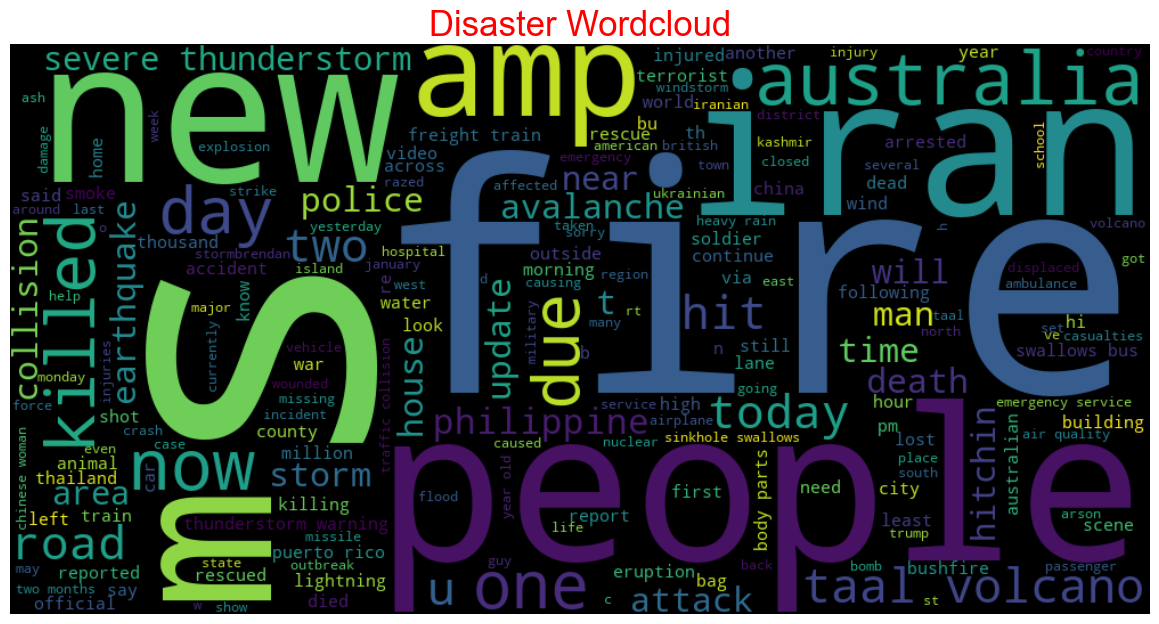

In [274]:
plt.figure(figsize=(14,6))
wordcloud = WordCloud(width=1000,height=500).generate(disaster)
plt.imshow(wordcloud,interpolation='bilinear',cmap='magma')
plt.axis('off')
plt.tight_layout()
plt.title('Disaster Wordcloud',fontsize= 25,color='Red')
plt.show()

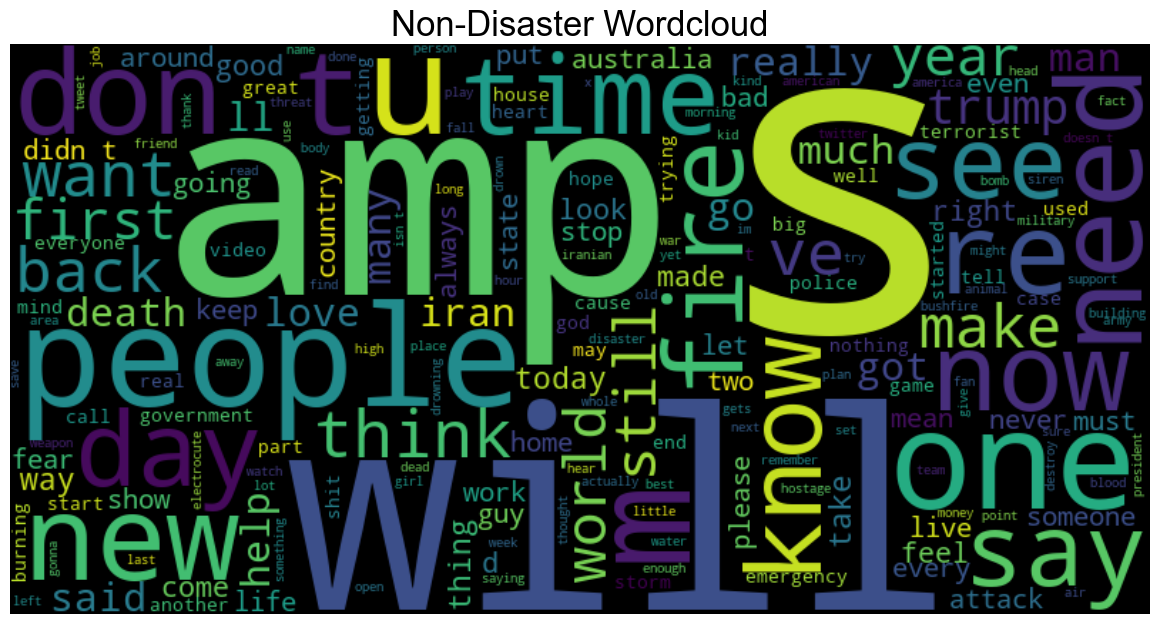

In [275]:
plt.figure(figsize=(14,6),frameon=True)
wordcloud = WordCloud(width=800,height=400).generate(non_disaster)
plt.imshow(wordcloud,interpolation='bilinear',cmap='Dark2')
plt.axis('off')
plt.tight_layout()
plt.title('Non-Disaster Wordcloud',fontsize= 25,color='Black')
plt.show()

In [276]:
df.head(5)

,id,keyword,location,text,target,length,text_clean,keyword_clean,tokens,pos_tags,tokens_pos_utiles,tokens_pos_sans_stopwords,tokens_lemmatized,keyword_lemma,loc_in_text
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1,125,communal violence in bhainsa telangana stones ...,ablaze,"[communal, violence, in, bhainsa, telangana, s...","[(communal, ADJ), (violence, NOUN), (in, ADP),...","[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone...",ablaze,False
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1,131,telangana section has been imposed in bhainsa ...,ablaze,"[telangana, section, has, been, imposed, in, b...","[(telangana, PROPN), (section, PROPN), (has, A...","[telangana, section, imposed, bhainsa, january...","[telangana, section, imposed, bhainsa, january...","[telangana, section, impose, bhainsa, january,...",ablaze,False
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1,63,arsonist sets cars ablaze at dealership,ablaze,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]",ablaze,False
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1,87,arsonist sets cars ablaze at dealership,ablaze,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]",ablaze,False
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0,140,lord jesus your love brings freedom and pardon...,ablaze,"[lord, jesus, your, love, brings, freedom, and...","[(lord, PROPN), (jesus, PROPN), (your, PRON), ...","[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, bring, freedom, pardon, fi...",ablaze,False


In [277]:
# Sélection des variables utiles pour la modélisation

# Variables explicatives
# Construction du texte final à partir des tokens lemmatisés
df["text_final"] = df["tokens_lemmatized"].apply(
    lambda tokens: " ".join(tokens)
)
X_text = df["text_final"]

X_keyword = df["keyword_lemma"]

# Variable cible
y = df["target"]

# Base finale
df_final = df[["text_final", "keyword_lemma", "target"]]

# Aperçu
df_final.head()


,text_final,keyword_lemma,target
0,communal violence bhainsa telangana stones pel...,ablaze,1
1,telangana section impose bhainsa january clash...,ablaze,1
2,arsonist set car ablaze dealership,ablaze,1
3,arsonist set car ablaze dealership,ablaze,1
4,lord jesus love bring freedom pardon fill holy...,ablaze,0


**Représentation vectorielle des tweets**

Après les différentes étapes de prétraitement (nettoyage, tokenisation, filtrage grammatical, suppression des stopwords et lemmatisation), les données textuelles doivent être transformées en représentations numériques afin de pouvoir être exploitées par les modèles de machine learning.

Plusieurs techniques de représentation vectorielle existent en traitement automatique du langage naturel (NLP), parmi lesquelles :

**One-Hot Encoding** ;
**Bag of Words (BoW)** ;
**TF-IDF (Term Frequency – Inverse Document Frequency)** ;
**Word Embeddings comme Word2Vec ou GloVe** ;
ainsi que les représentations contextuelles basées sur les Transformers.

Dans ce projet, deux approches seront retenues selon le type de modèle (hors deep learning) utilisé.

Pour les modèles de base (baseline models), notamment :

**la régression logistique**,
**le SVM**,
**et Naive Bayes**,

la méthode **TF-IDF** sera utilisée. Cette représentation est particulièrement adaptée aux modèles classiques de classification textuelle, car elle permet de mettre en valeur les mots les plus informatifs tout en restant simple, rapide et efficace sur des données textuelles de grande dimension.

En revanche, pour les modèles ensemblistes comme :

**Random Forest**,
**Gradient Boosting**,
et **XGBoost**,

une représentation plus dense et plus compacte sera privilégiée à l’aide des **Word Embeddings**. Contrairement à **TF-IDF**, ces représentations permettent de capturer certaines relations sémantiques entre les mots et sont généralement mieux adaptées aux modèles basés sur les arbres de décision.

# TF-IDF

In [278]:
from scipy.sparse import hstack
# Variables explicatives
X_text = df_final["text_final"].astype(str)
X_keyword = df_final["keyword_lemma"].astype(str)

# TF-IDF sur le texte principal
tfidf_text = TfidfVectorizer()
X_text_tfidf = tfidf_text.fit_transform(X_text)

# TF-IDF sur keyword
tfidf_keyword = TfidfVectorizer()
X_keyword_tfidf = tfidf_keyword.fit_transform(X_keyword)

# Combinaison numérique des deux matrices
X_tfidf = hstack([X_text_tfidf, X_keyword_tfidf])

In [279]:
print("Dimensions texte TF-IDF :", X_text_tfidf.shape)
print("Dimensions keyword TF-IDF :", X_keyword_tfidf.shape)
print("Dimensions finales :", X_tfidf.shape)

Dimensions texte TF-IDF : (11370, 17168)
Dimensions keyword TF-IDF : (11370, 190)
Dimensions finales : (11370, 17358)


In [280]:
# Affichage de la matrice TF-IDF
print(X_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 106889 stored elements and shape (11370, 17358)>
  Coords	Values
  (0, 2966)	0.3332286299374083
  (0, 16395)	0.2611931162022749
  (0, 1519)	0.2912910678286025
  (0, 15142)	0.2865131883751234
  (0, 14558)	0.34174673649687937
  (0, 11362)	0.3332286299374083
  (0, 10120)	0.25021136685768763
  (0, 7066)	0.42256224813239346
  (0, 16273)	0.24688986293468018
  (0, 13622)	0.22164215706615933
  (0, 34)	0.2733495186613768
  (0, 17168)	1.0
  (1, 1519)	0.3082759925114618
  (1, 15142)	0.3032195191303829
  (1, 13487)	0.3336711917567617
  (1, 7366)	0.3390657345623256
  (1, 7896)	0.4886962918624038
  (1, 2742)	0.3289128677766901
  (1, 4957)	0.27642305593042116
  (1, 6427)	0.26128579260793205
  (1, 11724)	0.3082759925114618
  (1, 17168)	1.0
  (2, 13622)	0.36063456373758934
  (2, 34)	0.4447677540915653
  (2, 831)	0.45306162146156126
  :	:
  (11367, 3130)	0.2766881261986978
  (11367, 952)	0.20034206459539772
  (11367, 1543)	0.3113615274668831


Plus lisible

In [281]:
# Conversion des premières lignes en DataFrame
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray()
)

tfidf_df.head()

,0,1,2,3,4,5,6,7,8,9,...,17348,17349,17350,17351,17352,17353,17354,17355,17356,17357
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Les modèles classiques 

In [287]:
X = df_final[["text_final", "keyword_lemma"]].copy()
y = df_final["target"].copy()

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [288]:
lr = LogisticRegression(max_iter=1000, random_state=42)
svc = SVC(kernel="linear", random_state=42)
mnb = MultinomialNB()

models = [
    ("Logistic Regression", lr),
    ("SVC", svc),
    ("MultinomialNB", mnb)
]

**Évaluation des modèles**


==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      9256
           1       0.85      0.40      0.54      2114

    accuracy                           0.88     11370
   macro avg       0.86      0.69      0.74     11370
weighted avg       0.87      0.88      0.86     11370



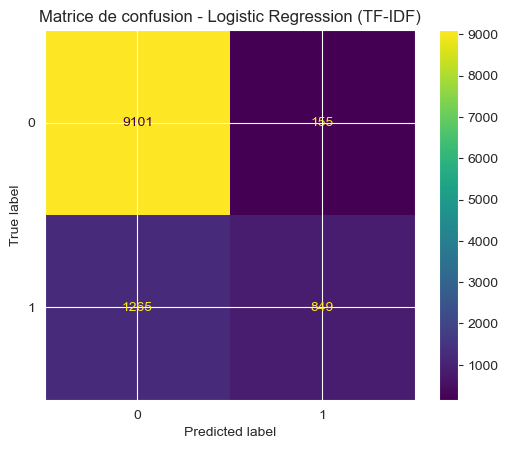


==================== SVC ====================
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      9256
           1       0.81      0.53      0.64      2114

    accuracy                           0.89     11370
   macro avg       0.85      0.75      0.79     11370
weighted avg       0.88      0.89      0.88     11370



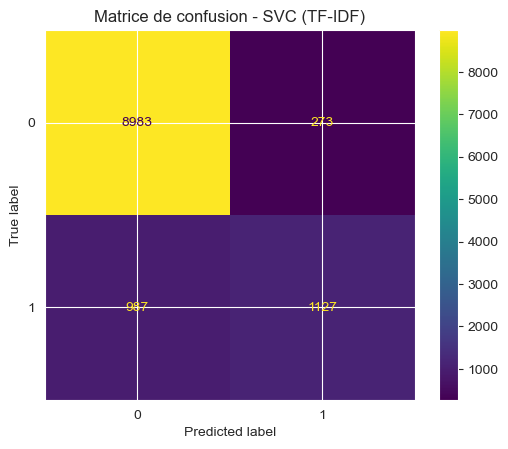


==================== MultinomialNB ====================
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      9256
           1       0.85      0.29      0.43      2114

    accuracy                           0.86     11370
   macro avg       0.85      0.64      0.68     11370
weighted avg       0.86      0.86      0.83     11370



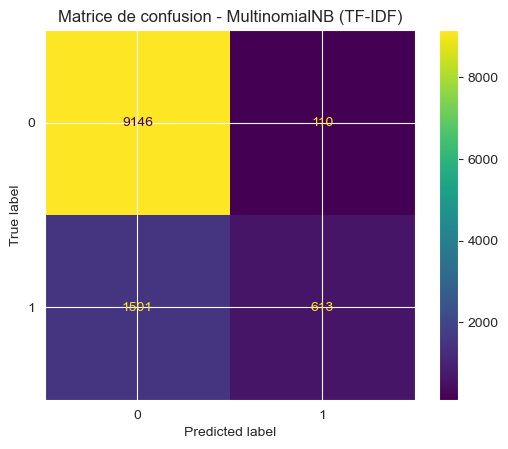

In [289]:
# Validation croisée
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Stockage des résultats
resultats_tfidf = []

# Boucle sur les modèles
for nom, modele in models:
    
    # Prédictions par validation croisée
    pred = cross_val_predict(modele, X_tfidf, y, cv=cv)
    # Accuracy
    acc = accuracy_score(y, pred)
    print(f"\n==================== {nom} ====================")
    
    # Rapport de classification
    print(classification_report(y, pred))
    
    # Matrice de confusion
    ConfusionMatrixDisplay(
        confusion_matrix(y, pred)
    ).plot()
    
    plt.title(f"Matrice de confusion - {nom} (TF-IDF)")
    plt.show()
    # Sauvegarde des résultats
    resultats_tfidf.append([nom, acc])

# Analyse comparative des modèles baseline

Les trois modèles testés (Régression Logistique, SVM et Naive Bayes) présentent des performances globalement satisfaisantes en termes d’**accuracy**, comprises entre **85 %** et **89 %**. Toutefois, une analyse plus fine des métriques révèle des différences importantes dans leur capacité à détecter les tweets de catastrophe (classe 1).

La **régression logistique** obtient une bonne **accuracy** globale (**87 %**), mais montre une faible capacité à détecter les catastrophes, avec un recall de seulement **0.36** pour la classe 1. Cela signifie qu’une grande partie des tweets réellement catastrophiques ne sont pas correctement identifiés.

Le modèle **SVM** se distingue comme le plus performant. Il atteint la meilleure accuracy (**89 %**) et présente un meilleur équilibre entre précision et rappel, notamment pour la classe 1 (recall de 0.51). Il est donc plus efficace pour détecter les tweets liés aux catastrophes, tout en conservant de bonnes performances globales.

Le modèle **Naive Bayes** obtient une accuracy correcte (**85 %**), mais il est très déséquilibré. Il identifie presque parfaitement les tweets non catastrophiques (recall proche de 1), mais échoue largement à détecter les catastrophes (recall de 0.22). Ce comportement montre qu’il est fortement biaisé vers la classe majoritaire.

Tableau récapitulatif

In [292]:
# Création du tableau récapitulatif des performances
resultats_tfidf = pd.DataFrame(
    resultats_tfidf,
    columns=["Modèle", "Accuracy"]
)

# Conversion en pourcentage
resultats_tfidf["Accuracy"] = (
    resultats_tfidf["Accuracy"] * 100
).round(2)

# Tri des résultats
resultats_tfidf = resultats_tfidf.sort_values(
    by="Accuracy",
    ascending=False
)

# Affichage
resultats_tfidf

,Modèle,Accuracy
1,SVC,88.92
0,Logistic Regression,87.51
2,MultinomialNB,85.83


# Les méthodes d'Ensemble

**Transformation vectorielle (Word Embeddings: Word2Vec)**

In [293]:
class Word2VecVectorizer(BaseEstimator, TransformerMixin):

    def __init__(self, vector_size=100, window=5, min_count=1, workers=1):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=["text_final", "keyword_lemma"])

        sentences_text = [str(text).split() for text in X["text_final"]]
        sentences_keyword = [str(text).split() for text in X["keyword_lemma"]]

        all_sentences = sentences_text + sentences_keyword

        self.w2v_model_ = Word2Vec(
            sentences=all_sentences,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers,
            seed=42
        )

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=["text_final", "keyword_lemma"])

        vectors = []

        for text, keyword in zip(X["text_final"], X["keyword_lemma"]):
            text_tokens = str(text).split()
            keyword_tokens = str(keyword).split()

            text_vectors = [
                self.w2v_model_.wv[word]
                for word in text_tokens
                if word in self.w2v_model_.wv
            ]

            keyword_vectors = [
                self.w2v_model_.wv[word]
                for word in keyword_tokens
                if word in self.w2v_model_.wv
            ]

            text_mean = np.mean(text_vectors, axis=0) if len(text_vectors) > 0 else np.zeros(self.vector_size)
            keyword_mean = np.mean(keyword_vectors, axis=0) if len(keyword_vectors) > 0 else np.zeros(self.vector_size)

            vectors.append(np.concatenate([text_mean, keyword_mean]))

        return np.array(vectors)

**Pipelines**

In [294]:

models_2 = [

    ("Random Forest", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])),

    
    ("XGBoost", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ])),

    
    ("Gradient Boosting", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])),

    
    ("KNN", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])),

    
    ("Voting Classifier", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", VotingClassifier(
            estimators=[
                ("rf", RandomForestClassifier(
                    n_estimators=100,
                    random_state=42,
                    n_jobs=-1
                )),
                
                ("xgb", XGBClassifier(
                    n_estimators=100,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    eval_metric="logloss"
                )),
                
                ("knn", KNeighborsClassifier(
                    n_neighbors=5
                ))
            ],
            voting="hard"
        ))
    ]))
]

**Evaluation des modèles**


==================== Random Forest ====================
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      9256
           1       0.77      0.32      0.45      2114

    accuracy                           0.86     11370
   macro avg       0.82      0.65      0.68     11370
weighted avg       0.85      0.86      0.83     11370



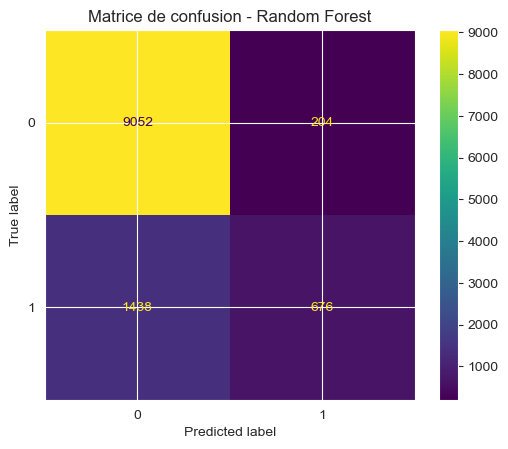


==================== XGBoost ====================
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      9256
           1       0.74      0.32      0.45      2114

    accuracy                           0.85     11370
   macro avg       0.80      0.65      0.68     11370
weighted avg       0.84      0.85      0.83     11370



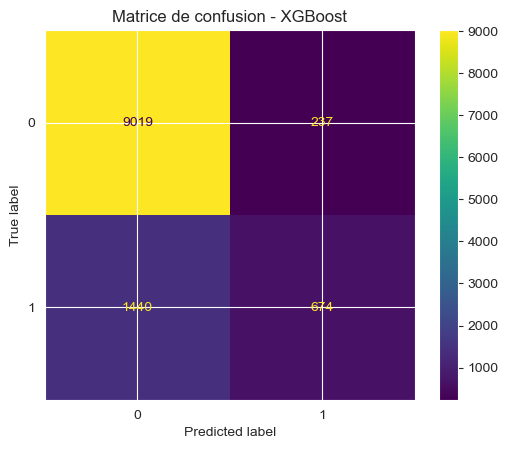


==================== Gradient Boosting ====================
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      9256
           1       0.74      0.20      0.31      2114

    accuracy                           0.84     11370
   macro avg       0.79      0.59      0.61     11370
weighted avg       0.82      0.84      0.80     11370



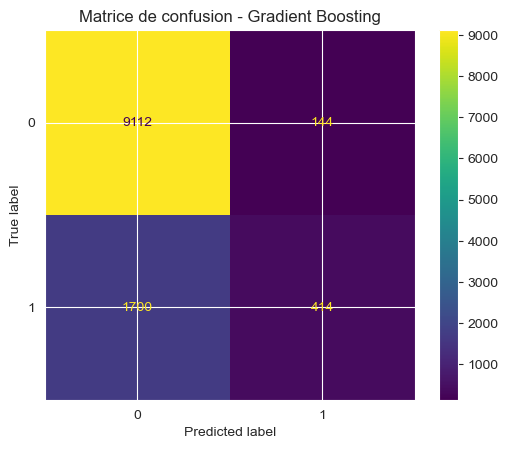


==================== KNN ====================
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      9256
           1       0.52      0.27      0.35      2114

    accuracy                           0.82     11370
   macro avg       0.68      0.61      0.62     11370
weighted avg       0.79      0.82      0.79     11370



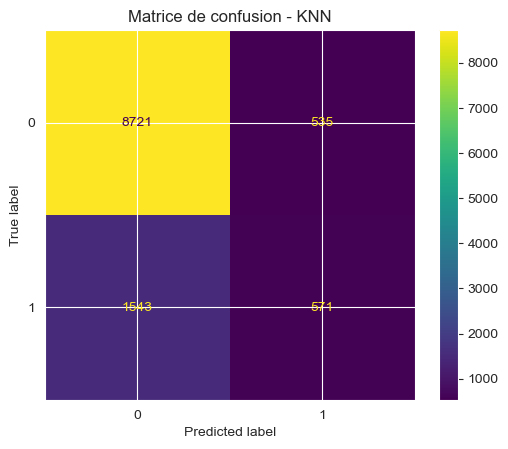


==================== Voting Classifier ====================
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      9256
           1       0.77      0.29      0.42      2114

    accuracy                           0.85     11370
   macro avg       0.81      0.64      0.67     11370
weighted avg       0.84      0.85      0.82     11370



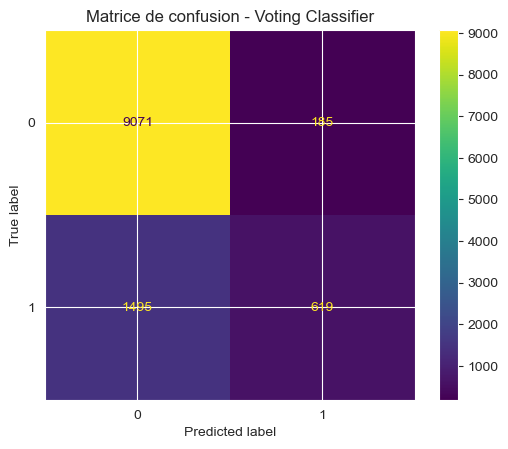

In [295]:
# Validation croisée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Liste des résultats
resultats_2 = []

# Boucle sur les modèles
for nom, modele in models_2:
    
    print(f"\n==================== {nom} ====================")
    
    # Prédictions
    pred = cross_val_predict(
        modele,
        X,
        y,
        cv=cv
    )
    
    # Métriques
    acc = accuracy_score(y, pred)
    precision = precision_score(y, pred)
    recall = recall_score(y, pred)
    f1 = f1_score(y, pred)
    
    # Rapport détaillé
    print(classification_report(y, pred))
    
    # Matrice de confusion
    ConfusionMatrixDisplay(
        confusion_matrix(y, pred)
    ).plot()
    
    plt.title(f"Matrice de confusion - {nom}")
    plt.show()
    
    # Sauvegarde
    resultats_2.append([
        nom,
        acc,
        precision,
        recall,
        f1
    ])

**Tableau récapitulatif des modèles**

In [296]:
# Tableau récapitulatif
df_resultats_2 = pd.DataFrame(
    resultats_2,
    columns=[
        "Modèle",
        "Accuracy",
        "Précision",
        "Recall",
        "F1-score"
    ]
)

# Conversion en pourcentage
colonnes_scores = [
    "Accuracy",
    "Précision",
    "Recall",
    "F1-score"
]

df_resultats_2[colonnes_scores] = (
    df_resultats_2[colonnes_scores] * 100
).round(2)

# Tri selon le F1-score
df_resultats_2 = df_resultats_2.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

# Affichage
df_resultats_2

,Modèle,Accuracy,Précision,Recall,F1-score
0,Random Forest,85.56,76.82,31.98,45.16
1,XGBoost,85.25,73.98,31.88,44.56
2,Voting Classifier,85.22,76.99,29.28,42.43
3,KNN,81.72,51.63,27.01,35.47
4,Gradient Boosting,83.78,74.19,19.58,30.99


L’analyse des performances montre que les modèles ensemblistes obtiennent des résultats globalement corrects, avec des niveaux d’accuracy relativement proches. Le modèle Random Forest apparaît comme le plus performant, avec le meilleur F1-score (45.16 %) ainsi qu’un bon compromis entre précision et rappel. Il est suivi de près par XGBoost, dont les performances restent très similaires.

Le Voting Classifier présente également des résultats satisfaisants, mais sans réellement surpasser les meilleurs modèles individuels. Quant au KNN, il obtient des performances plus modestes, notamment en raison d’un rappel relativement faible. Enfin, Gradient Boosting est le modèle le moins performant dans cette configuration, avec un F1-score plus faible malgré une précision correcte.

De manière générale, les résultats montrent que les modèles ensemblistes parviennent à bien identifier les tweets non catastrophiques (classe majoritaire), mais rencontrent davantage de difficultés pour détecter correctement les tweets liés aux catastrophes, comme en témoigne le rappel relativement faible observé sur l’ensemble des modèles.

**Optimisation des hyperparamètres**

In [300]:
# Pipeline Random Forest avec Word2Vec
pipe_rf = Pipeline([
    ("word2vec", Word2VecVectorizer(
        vector_size=100,
        window=5,
        min_count=1,
        workers=1
    )),
    
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Grille légère d'hyperparamètres
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)
grid_rf.fit(X, y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,vector_size,100


In [ ]:
print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print("Meilleur F1-score :")
print(round(grid_rf.best_score_ * 100, 2), "%")